In [9]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Load the data
data = pd.read_csv('cardio.csv', delimiter=';')

# Drop 'id' column if it exists
if 'id' in data.columns:
    data = data.drop('id', axis=1)

# Preprocessing
encoder = LabelEncoder()
data['gender'] = encoder.fit_transform(data['gender'])
data['cholesterol'] = encoder.fit_transform(data['cholesterol'])
data['gluc'] = encoder.fit_transform(data['gluc'])
data['smoke'] = encoder.fit_transform(data['smoke'])
data['alco'] = encoder.fit_transform(data['alco'])
data['active'] = encoder.fit_transform(data['active'])
data['cardio'] = encoder.fit_transform(data['cardio'])

# Features and target
X = data.drop('cardio', axis=1)
y = data['cardio']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train the model
model = GaussianNB()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

# --- User Input Section ---

# Take user input
user_input = {
    'age': int(input("Enter age (in days): ")),
    'gender': int(input("Enter gender (1 = female, 0 = male): ")),
    'height': int(input("Enter height (in cm): ")),
    'weight': int(input("Enter weight (in kg): ")),
    'ap_hi': int(input("Enter systolic blood pressure (ap_hi): ")),
    'ap_lo': int(input("Enter diastolic blood pressure (ap_lo): ")),
    'cholesterol': int(input("Enter cholesterol level (1 = normal, 2 = above normal, 3 = well above normal): ")),
    'gluc': int(input("Enter glucose level (1 = normal, 2 = above normal, 3 = well above normal): ")),
    'smoke': int(input("Do you smoke? (0 = No, 1 = Yes): ")),
    'alco': int(input("Do you drink alcohol? (0 = No, 1 = Yes): ")),
    'active': int(input("Are you physically active? (0 = No, 1 = Yes): "))
}

# Convert to DataFrame
new_data = pd.DataFrame([user_input])

#  Ensure column order matches
new_data = new_data[X.columns]

# Prediction
prediction = model.predict(new_data)
probabilities = model.predict_proba(new_data)

# Output
print(f"\nProbability of having cardiovascular disease: {probabilities[0][1] * 100:.2f}%")
print(f"Probability of being healthy: {probabilities[0][0] * 100:.2f}%")

if prediction[0] == 1:
    print("Prediction: The person is predicted to have cardiovascular disease.")
else:
    print("Prediction: The person is predicted to be free of cardiovascular disease.")


Accuracy: 59.49%


Enter age (in days):  60
Enter gender (1 = female, 0 = male):  1
Enter height (in cm):  160
Enter weight (in kg):  80
Enter systolic blood pressure (ap_hi):  135
Enter diastolic blood pressure (ap_lo):  90
Enter cholesterol level (1 = normal, 2 = above normal, 3 = well above normal):  1
Enter glucose level (1 = normal, 2 = above normal, 3 = well above normal):  3
Do you smoke? (0 = No, 1 = Yes):  0
Do you drink alcohol? (0 = No, 1 = Yes):  0
Are you physically active? (0 = No, 1 = Yes):  0



Probability of having cardiovascular disease: 7.87%
Probability of being healthy: 92.13%
Prediction: The person is predicted to be free of cardiovascular disease.


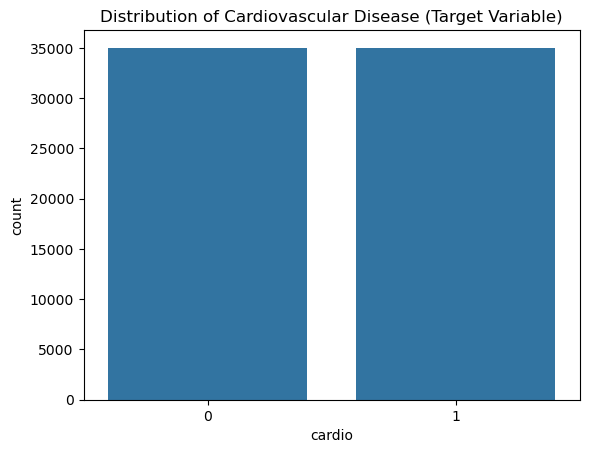

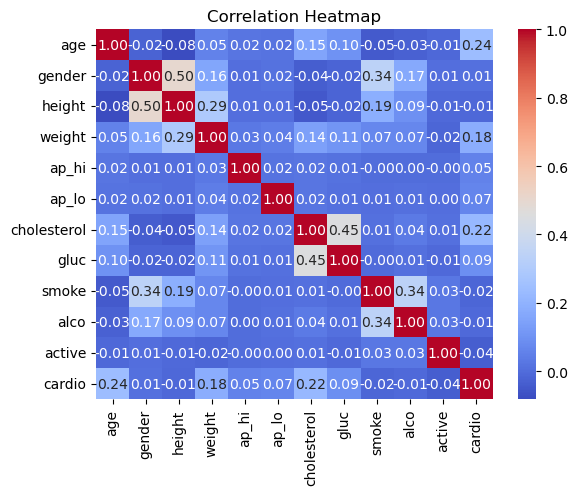

In [18]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting distribution of cardiovascular disease target variable
sns.countplot(x='cardio', data=data)
plt.title('Distribution of Cardiovascular Disease (Target Variable)')
plt.show()

# Plotting correlation heatmap
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Initialize models
nb_model = GaussianNB()
rf_model = RandomForestClassifier(random_state=42)
svc_model = SVC(random_state=42)

# Train and evaluate each model
for model, name in zip([nb_model, rf_model, svc_model], ['Naive Bayes', 'Random Forest', 'SVM']):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f'{name} Accuracy: {accuracy * 100:.2f}%')

Naive Bayes Accuracy: 59.49%
Random Forest Accuracy: 71.55%
SVM Accuracy: 60.47%


In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import numpy as np
# Train multiple models
nb_model = GaussianNB()
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit both models on training data
nb_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# Make predictions
nb_pred = nb_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

# Combine predictions using Bayesian Model Averaging
# Let's assume equal weights for simplicity (you can adjust weights based on model performance)
bma_pred = (nb_pred + rf_pred) / 2
bma_pred = np.round(bma_pred).astype(int)  # Convert to binary predictions (0 or 1)

# Evaluate performance
accuracy = accuracy_score(y_test, bma_pred)
print(f'Accuracy of Bayesian Model Averaging: {accuracy * 100:.2f}%')

Accuracy of Bayesian Model Averaging: 60.02%
